# Give Me Some Credit

## Import libraries, functions and data

In [232]:
import pandas as pd
import seaborn as sns
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

import jax
import jax.numpy as jnp

# from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import roc_curve, roc_auc_score, accuracy_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression

from xgboost import XGBClassifier
import lightgbm as lgb
from catboost import CatBoostClassifier

In [233]:
def plot_roc_curve(fpr, tpr, label="ROC Curve"):
    plt.figure(figsize=(6, 6))

    plt.plot(fpr, tpr, label=label)
    plt.plot([0, 1], [0, 1], color='red', linestyle='--')

    plt.axis([0, 1, 0, 1])
    plt.xlabel("False Positive Rate (1 - SPECIFICITY)")
    plt.ylabel("True Positive Rate (SENSITIVITY)")
    plt.title(label)

    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

In [234]:
train_df = pd.read_csv("../data/cs-training.csv")
test_df = pd.read_csv("../data/cs-test.csv")

## Exploratory data analysis

In [235]:
train_df.head()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [236]:
test_df.head()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,NaN,0.885519,43,0,0.177513,5700.0,4,0,0,0,0.0
1,2,NaN,0.463295,57,0,0.527237,9141.0,15,0,4,0,2.0
2,3,NaN,0.043275,59,0,0.687648,5083.0,12,0,1,0,2.0
3,4,NaN,0.280308,38,1,0.925961,3200.0,7,0,2,0,0.0
4,5,NaN,1.000000,27,0,0.019917,3865.0,4,0,0,0,1.0


In [237]:
train_df.rename(columns={'Unnamed: 0':'ID'}, inplace=True)
test_df.rename(columns={'Unnamed: 0':'ID'}, inplace=True)

In [238]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   ID                                    150000 non-null  int64  
 1   SeriousDlqin2yrs                      150000 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 3   age                                   150000 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 5   DebtRatio                             150000 non-null  float64
 6   MonthlyIncome                         120269 non-null  float64
 7   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 8   NumberOfTimes90DaysLate               150000 non-null  int64  
 9   NumberRealEstateLoansOrLines          150000 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 11  

In [239]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101503 entries, 0 to 101502
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   ID                                    101503 non-null  int64  
 1   SeriousDlqin2yrs                      0 non-null       float64
 2   RevolvingUtilizationOfUnsecuredLines  101503 non-null  float64
 3   age                                   101503 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  101503 non-null  int64  
 5   DebtRatio                             101503 non-null  float64
 6   MonthlyIncome                         81400 non-null   float64
 7   NumberOfOpenCreditLinesAndLoans       101503 non-null  int64  
 8   NumberOfTimes90DaysLate               101503 non-null  int64  
 9   NumberRealEstateLoansOrLines          101503 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  101503 non-null  int64  
 11  

In [240]:
train_df.describe().round(decimals=2)

,ID,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.00,150000.00,150000.00,150000.00,150000.00,150000.00,120269.00,150000.00,150000.00,150000.00,150000.00,146076.00
mean,75000.50,0.07,6.05,52.30,0.42,353.01,6670.22,8.45,0.27,1.02,0.24,0.76
std,43301.41,0.25,249.76,14.77,4.19,2037.82,14384.67,5.15,4.17,1.13,4.16,1.12
min,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,37500.75,0.00,0.03,41.00,0.00,0.18,3400.00,5.00,0.00,0.00,0.00,0.00
50%,75000.50,0.00,0.15,52.00,0.00,0.37,5400.00,8.00,0.00,1.00,0.00,0.00
75%,112500.25,0.00,0.56,63.00,0.00,0.87,8249.00,11.00,0.00,2.00,0.00,1.00
max,150000.00,1.00,50708.00,109.00,98.00,329664.00,3008750.00,58.00,98.00,54.00,98.00,20.00


In [241]:
test_df.describe().round(decimals=2)

,ID,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,101503.00,0.0,101503.00,101503.00,101503.00,101503.00,81400.00,101503.00,101503.00,101503.00,101503.00,98877.00
mean,50752.00,NaN,5.31,52.41,0.45,344.48,6855.04,8.45,0.30,1.01,0.27,0.77
std,29301.54,NaN,196.16,14.78,4.54,1632.60,36508.60,5.14,4.52,1.11,4.50,1.14
min,1.00,NaN,0.00,21.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,25376.50,NaN,0.03,41.00,0.00,0.17,3408.00,5.00,0.00,0.00,0.00,0.00
50%,50752.00,NaN,0.15,52.00,0.00,0.36,5400.00,8.00,0.00,1.00,0.00,0.00
75%,76127.50,NaN,0.56,63.00,0.00,0.85,8200.00,11.00,0.00,2.00,0.00,1.00
max,101503.00,NaN,21821.00,104.00,98.00,268326.00,7727000.00,85.00,98.00,37.00,98.00,43.00


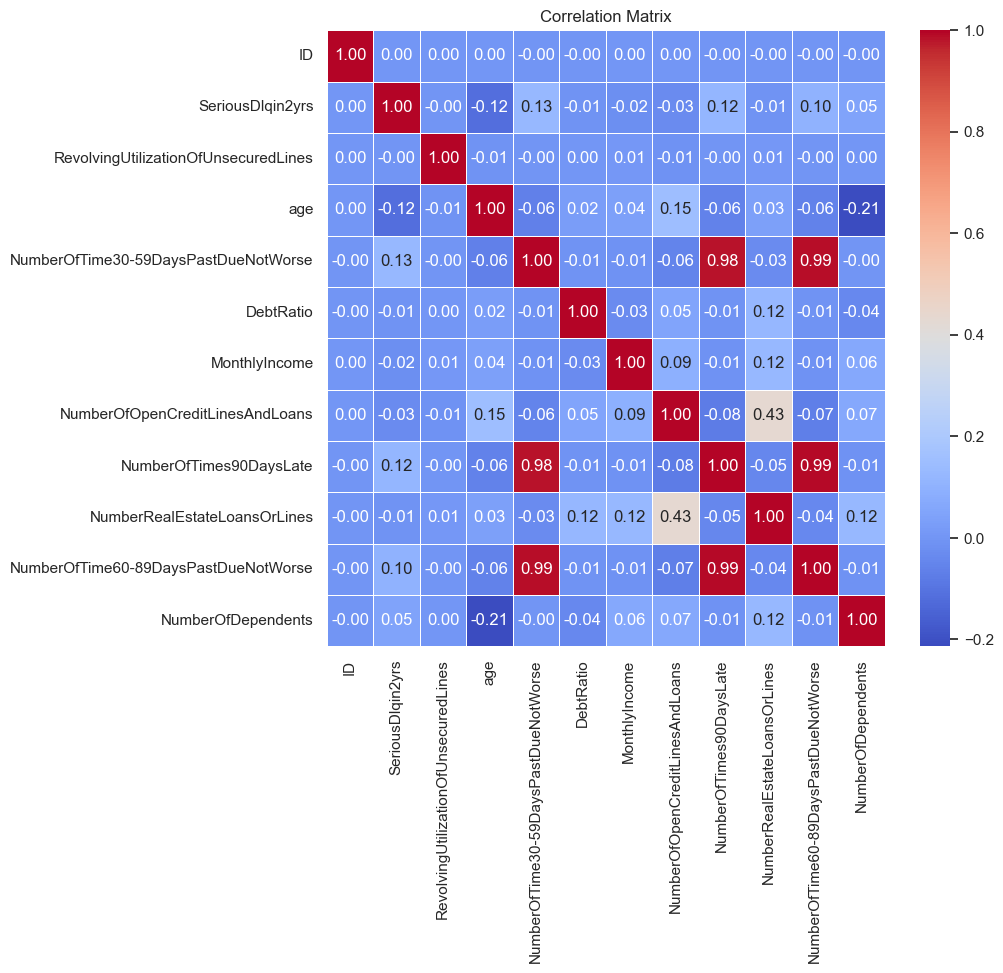

In [242]:
corr = train_df.corr()
fig = plt.figure(figsize=(9,8))
plt.title('Correlation Matrix')
ax = sns.heatmap(corr, annot=True, fmt='.2f', cmap="coolwarm", linewidths=0.5)
plt.show()

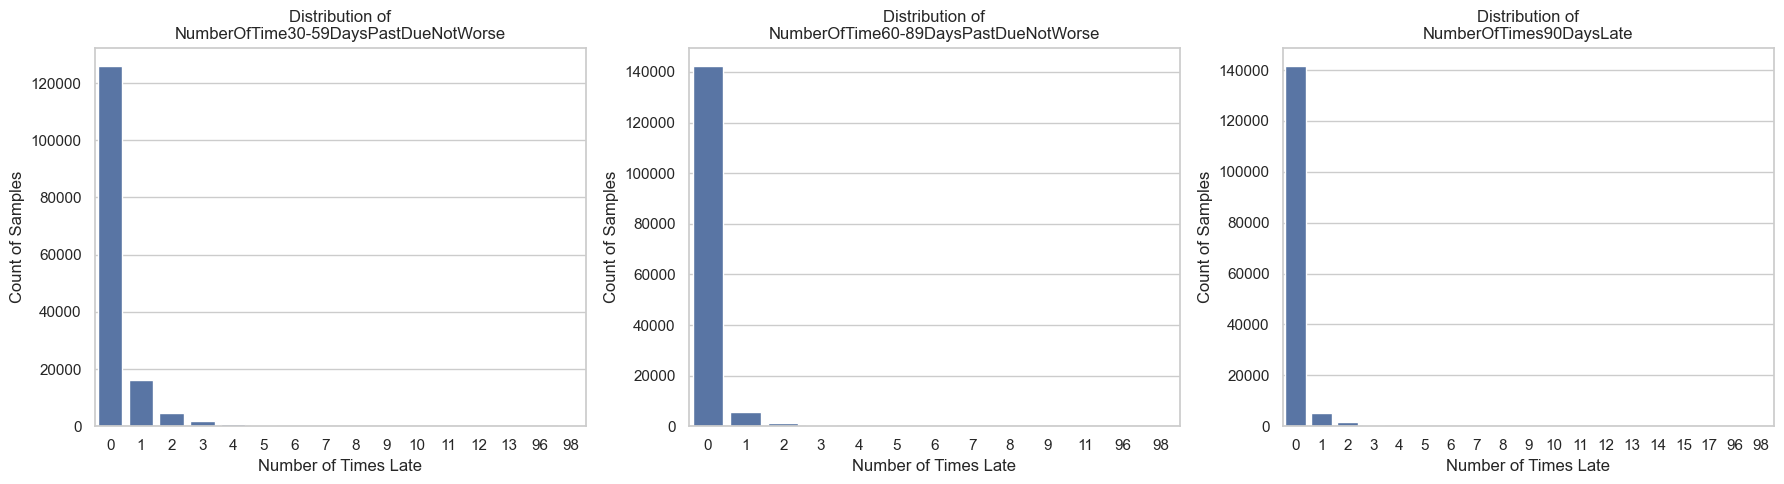

In [243]:
late_cols = [
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTime60-89DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate'
]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(late_cols):
    sns.countplot(
        data=train_df,
        x=col,
        ax=axes[i]
    )
    axes[i].set_title(f'Distribution of\n{col}')
    axes[i].set_xlabel('Number of Times Late')
    axes[i].set_ylabel('Count of Samples')
plt.tight_layout()
plt.show()

In [244]:
count_age_zero = (train_df['age'] == 0).sum()
print(f"Number of samples with age = 0: {count_age_zero}")

Number of samples with age = 0: 1


In [245]:
wrong_mask = (train_df[late_cols[0]].isin([96, 98])) | \
             (train_df[late_cols[1]].isin([96, 98])) | \
             (train_df[late_cols[2]].isin([96, 98]))
wrong_samples = train_df[wrong_mask]

combinations_table = wrong_samples[late_cols].value_counts().reset_index(name='Count')
# wrong_samples[late_cols]: filtered dataset with corrupted rows only
# .value_counts(): it looks for rows that has the same three numbers and counts how many times that combination appears
# .reset_index(name='Count'): it flattens the .value_counts() output into a standard dataframe

print("There are " + str(len(wrong_samples)) + " corrupted samples:")
combinations_table.style.hide(axis="index")

There are 269 corrupted samples:


NumberOfTime30-59DaysPastDueNotWorse,NumberOfTime60-89DaysPastDueNotWorse,NumberOfTimes90DaysLate,Count
98,98,98,264
96,96,96,5


In [246]:
print(train_df.duplicated().value_counts())
print(test_df.duplicated().value_counts())
# no duplicated rows (all False)

False    150000
Name: count, dtype: int64
False    101503
Name: count, dtype: int64


In [247]:
mis_val = train_df.isnull().sum()
mis_val_percent = 100 * train_df.isnull().sum() / len(train_df)
mis_val_table = pd.concat([mis_val, mis_val_percent], axis=1)
mis_val_table_ren_columns = mis_val_table.rename(
columns = {0 : 'Missing Values', 1 : '% of Total Values'})
mis_val_table_ren_columns = mis_val_table_ren_columns[
    mis_val_table_ren_columns.iloc[:,1] != 0].sort_values(
'% of Total Values', ascending=False).round(1)
print ("There are " + str(mis_val_table_ren_columns.shape[0]) +
      " columns that have missing values:")
mis_val_table_ren_columns

There are 2 columns that have missing values:


,Missing Values,% of Total Values
MonthlyIncome,29731,19.8
NumberOfDependents,3924,2.6


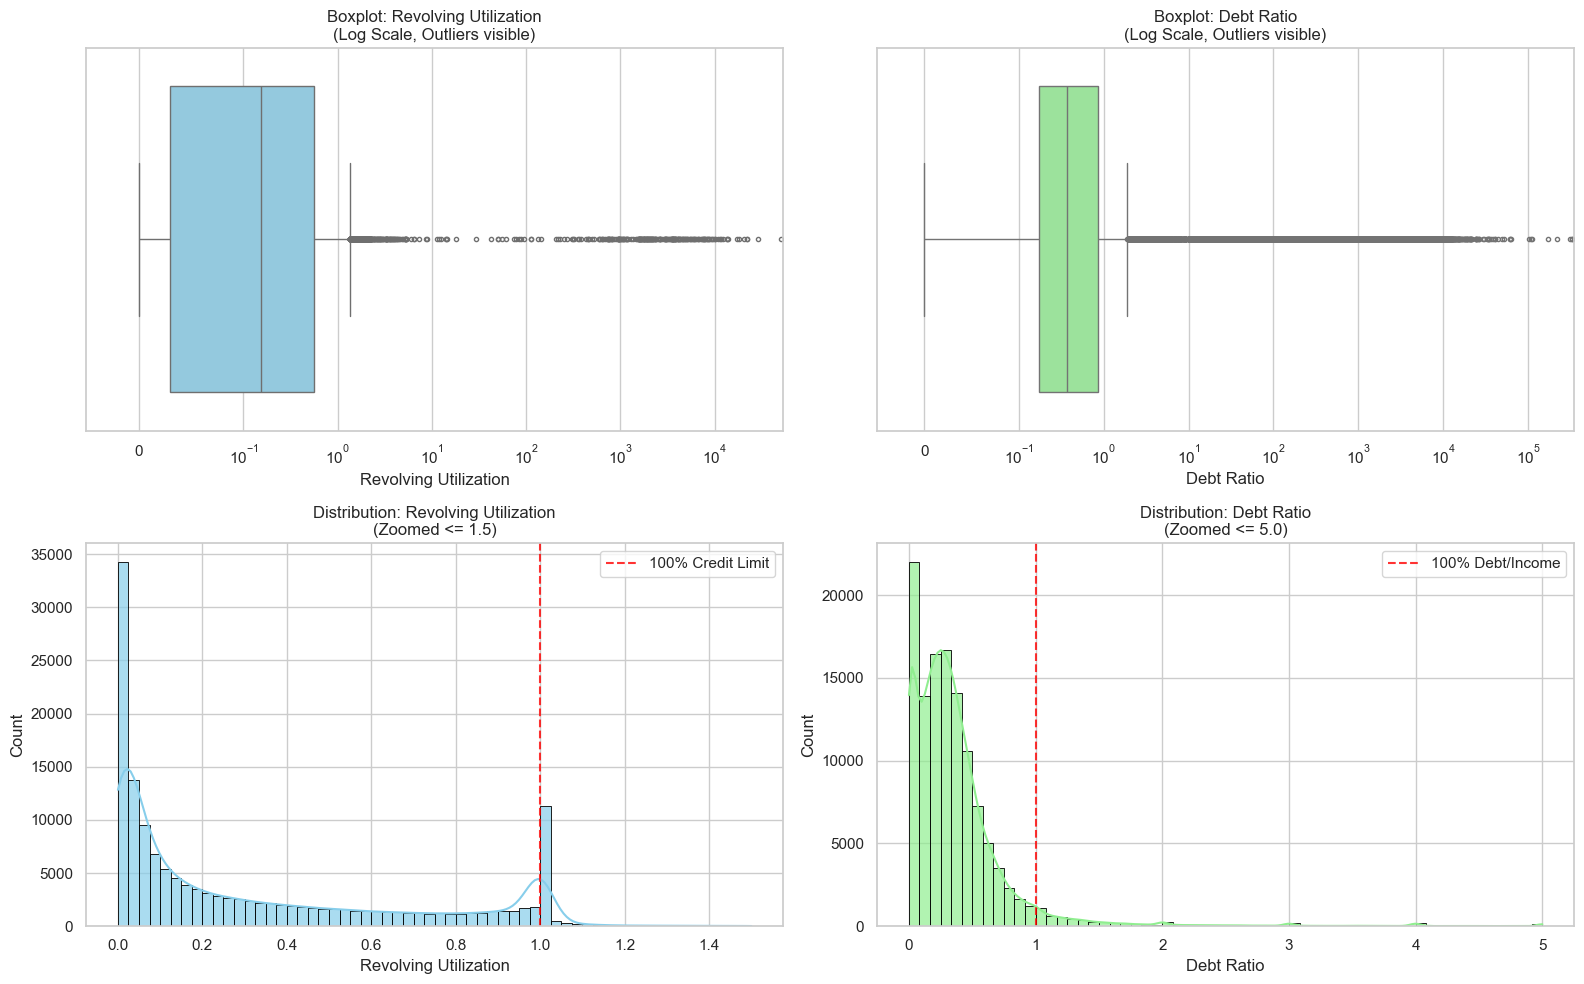

In [248]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Impostiamo un tema globale più pulito e leggibile
sns.set_theme(style="whitegrid")

# Creiamo la griglia 2x2
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# --- RIGA 1: BOXPLOT MIGLIORATI ---
# Manteniamo symlog per vedere gli outlier, ma tagliamo via la parte negativa dell'asse X

sns.boxplot(x=train_df['RevolvingUtilizationOfUnsecuredLines'], ax=axes[0, 0], color='skyblue', fliersize=3)
axes[0, 0].set_title('Boxplot: Revolving Utilization\n(Log Scale, Outliers visible)', fontsize=12)
axes[0, 0].set_xlabel('Revolving Utilization')
axes[0, 0].set_xscale('symlog', linthresh=0.1)
axes[0, 0].set_xlim(left=-0.05) # <-- Questo nasconde i numeri negativi inutili!

sns.boxplot(x=train_df['DebtRatio'], ax=axes[0, 1], color='lightgreen', fliersize=3)
axes[0, 1].set_title('Boxplot: Debt Ratio\n(Log Scale, Outliers visible)', fontsize=12)
axes[0, 1].set_xlabel('Debt Ratio')
axes[0, 1].set_xscale('symlog', linthresh=0.1)
axes[0, 1].set_xlim(left=-0.05) # <-- Come sopra


# --- RIGA 2: ISTOGRAMMI CON LINEE DI RIFERIMENTO ---
# Aggiungiamo più bin, la curva KDE anche al DebtRatio e delle linee rosse tratteggiate
# per indicare visivamente il "limite logico" di 1.0 (100%)

zoom_revolving = train_df[train_df['RevolvingUtilizationOfUnsecuredLines'] <= 1.5]['RevolvingUtilizationOfUnsecuredLines']
sns.histplot(zoom_revolving, bins=60, ax=axes[1, 0], color='skyblue', kde=True, edgecolor='black', alpha=0.7)
# Linea rossa per indicare l'uso del 100% del limite di credito
axes[1, 0].axvline(x=1.0, color='red', linestyle='--', linewidth=1.5, alpha=0.8, label='100% Credit Limit')
axes[1, 0].set_title('Distribution: Revolving Utilization\n(Zoomed <= 1.5)', fontsize=12)
axes[1, 0].set_xlabel('Revolving Utilization')
axes[1, 0].set_ylabel('Count')
axes[1, 0].legend()

zoom_debt = train_df[train_df['DebtRatio'] <= 5.0]['DebtRatio']
sns.histplot(zoom_debt, bins=60, ax=axes[1, 1], color='lightgreen', kde=True, edgecolor='black', alpha=0.7)
# Linea rossa per indicare dove il debito eguaglia esattamente il reddito (100%)
axes[1, 1].axvline(x=1.0, color='red', linestyle='--', linewidth=1.5, alpha=0.8, label='100% Debt/Income')
axes[1, 1].set_title('Distribution: Debt Ratio\n(Zoomed <= 5.0)', fontsize=12)
axes[1, 1].set_xlabel('Debt Ratio')
axes[1, 1].set_ylabel('Count')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# Resettiamo il tema di seaborn al default nel caso ti serva per altri plot
# sns.reset_orig()

In [249]:
wrong_revolving = (train_df['RevolvingUtilizationOfUnsecuredLines'] > 2.0).sum()
print(f"Samples with RevolvingUtilization > 2.0: {wrong_revolving}")
print(f"99% of RevolvingUtilization: {train_df['RevolvingUtilizationOfUnsecuredLines'].quantile(0.99)}")

Samples with RevolvingUtilization > 2.0: 371
99% of RevolvingUtilization: 1.0929557681400022


In [250]:
wrong_debt = (train_df['DebtRatio'] > 10.0).sum()
print(f"Samples with DebtRatio > 10.0: {wrong_debt}")
print(f"99% of DebtRatio: {train_df['DebtRatio'].quantile(0.99)}")

Samples with DebtRatio > 10.0: 28877
99% of DebtRatio: 4979.040000000037


## Imputing and cleaning

We fix *MonthlyIncome* and *NumberOfDependents*

In [251]:
inc_median = train_df['MonthlyIncome'].median()
dep_median = train_df['NumberOfDependents'].median()

inc_na_mask = train_df['MonthlyIncome'].isna()

train_df['MonthlyIncome'] = train_df['MonthlyIncome'].fillna(inc_median)
train_df['NumberOfDependents'] = train_df['NumberOfDependents'].fillna(dep_median).astype(int)

We fix *age*, *RevolvingUtilizationOfUnsecuredLines*, *DebtRatio*

In [252]:
train_df = train_df[train_df['age'] > 0]
train_df = train_df[train_df['RevolvingUtilizationOfUnsecuredLines'] <= 2.0]

train_df.loc[inc_na_mask, 'DebtRatio'] = train_df.loc[inc_na_mask, 'DebtRatio'] / inc_median
print(f"Samples with DebtRatio > 10.0 after MonthlyIncome imputation: {(train_df['DebtRatio'] > 10.0).sum()}")
train_df = train_df[train_df['DebtRatio'] <= 10.0]

Samples with DebtRatio > 10.0 after MonthlyIncome imputation: 2109


We fix *NumberOfTime30-59DaysPastDueNotWorse*, *NumberOfTime60-89DaysPastDueNotWorse* and *NumberOfTimes90DaysLate*

In [253]:
for col in late_cols:
    train_df = train_df[~train_df[col].isin([96, 98])]

In [254]:
print(f"New number of training samples: {len(train_df)}")

New number of training samples: 147250


## More data analysis

In [255]:
train_df.describe().round(decimals=2)

,ID,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,147250.00,147250.00,147250.00,147250.00,147250.00,147250.00,147250.00,147250.00,147250.00,147250.00,147250.00,147250.00
mean,75011.80,0.07,0.32,52.38,0.25,0.36,6511.08,8.48,0.09,1.02,0.06,0.74
std,43301.59,0.25,0.35,14.75,0.70,0.46,12983.54,5.14,0.48,1.13,0.33,1.11
min,1.00,0.00,0.00,21.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,37516.25,0.00,0.03,41.00,0.00,0.12,4000.00,5.00,0.00,0.00,0.00,0.00
50%,75025.50,0.00,0.15,52.00,0.00,0.28,5400.00,8.00,0.00,1.00,0.00,0.00
75%,112521.75,0.00,0.55,63.00,0.00,0.47,7467.00,11.00,0.00,2.00,0.00,1.00
max,150000.00,1.00,2.00,109.00,13.00,10.00,3008750.00,58.00,17.00,54.00,11.00,20.00


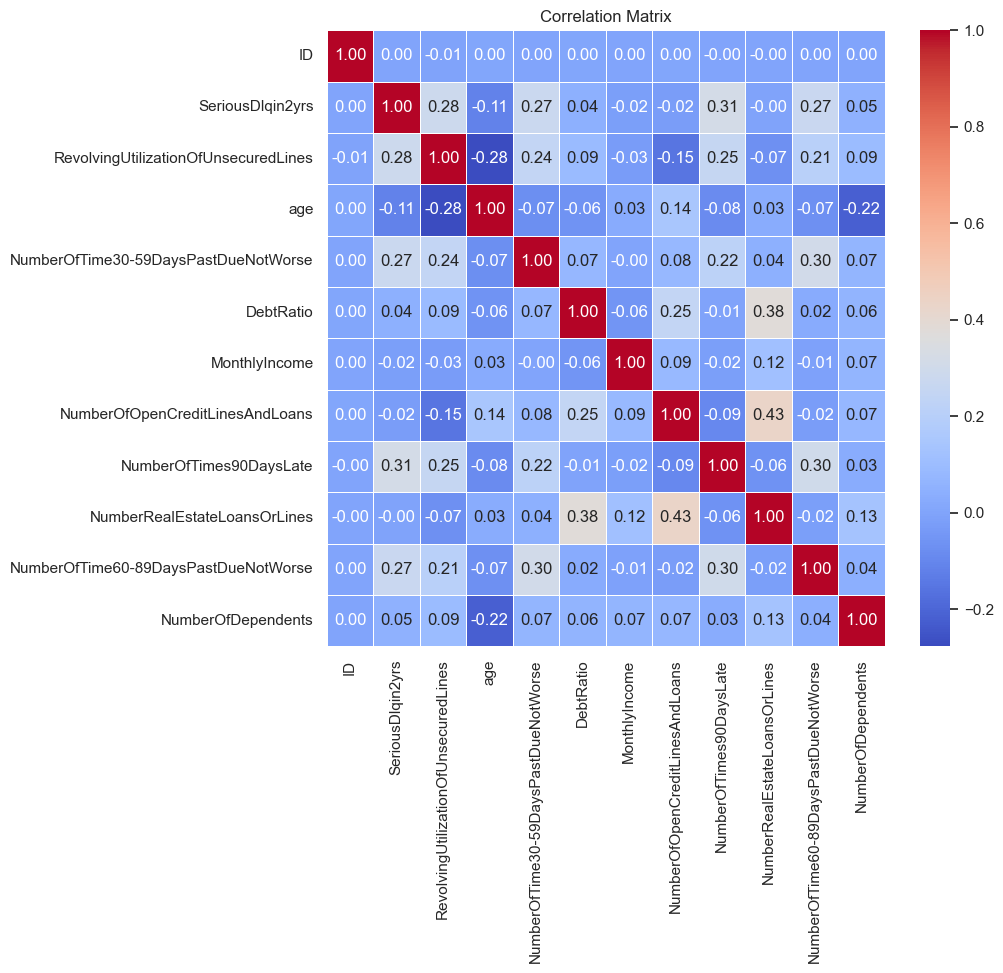

In [256]:
corr = train_df.corr()
fig = plt.figure(figsize=(9,8))
plt.title('Correlation Matrix')
ax = sns.heatmap(corr, annot=True, fmt='.2f', cmap="coolwarm", linewidths=0.5)
plt.show()

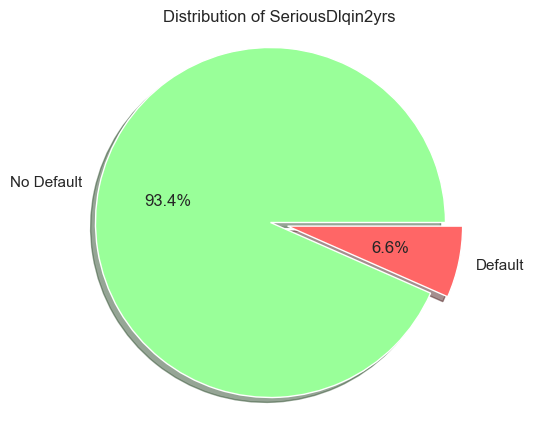

In [257]:
target_counts = train_df['SeriousDlqin2yrs'].value_counts()

plt.figure(figsize=(5, 5))
plt.pie(
    target_counts,
    labels=['No Default', 'Default'],
    autopct='%1.1f%%', # it automatically computes percentages
    colors=['#99ff99', '#ff6666'],
    explode=(0, 0.1), # highlight the Default slice
    shadow=True
)
plt.title('Distribution of SeriousDlqin2yrs')
plt.axis('equal')
plt.show()

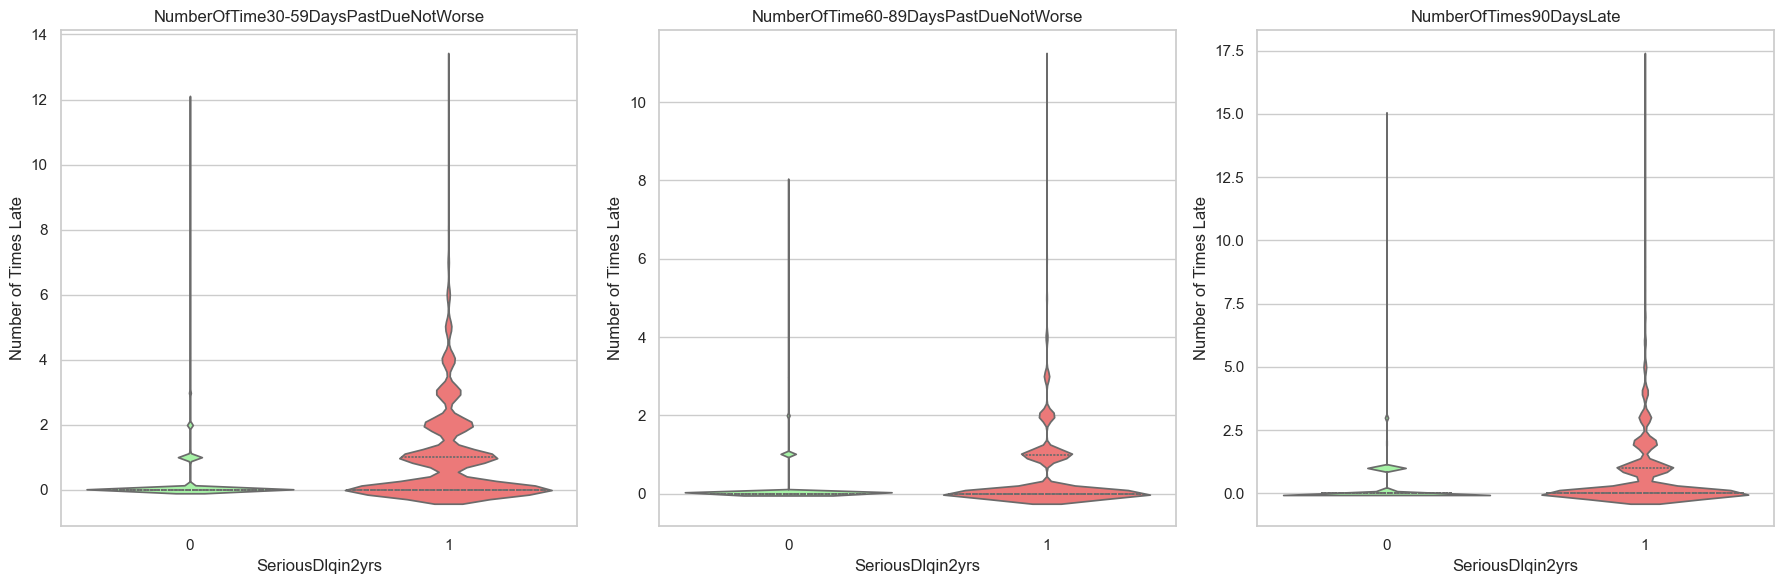

In [258]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, feature in enumerate(late_cols):
    sns.violinplot(
        data=train_df,
        x='SeriousDlqin2yrs',
        y=feature,
        ax=axes[i],
        hue='SeriousDlqin2yrs',
        palette=['#99ff99', '#ff6666'],
        inner='quartile',
        legend=False
    )
    axes[i].set_title(feature)
    axes[i].set_xlabel('SeriousDlqin2yrs')
    axes[i].set_ylabel('Number of Times Late')
plt.tight_layout()
plt.show()

In [259]:
# add some other visualizations

## Model

In [260]:
X = train_df.drop(['SeriousDlqin2yrs', 'ID'], axis=1)
y = train_df['SeriousDlqin2yrs']

# W = test_df.drop(['SeriousDlqin2yrs', 'ID'], axis=1)
# z = test_df['SeriousDlqin2yrs']

In [261]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=123, stratify=y
)

train_mean = X_train.mean(axis=0)
train_std = X_train.std(axis=0)

X_train_scaled = (X_train - train_mean) / train_std
X_test_scaled = (X_test - train_mean) / train_std

## Logistic Regression

In [262]:
X_train_array = np.array(X_train_scaled)
y_train_array = np.array(y_train)
X_test_array = np.array(X_test_scaled)
y_test_array = np.array(y_test)

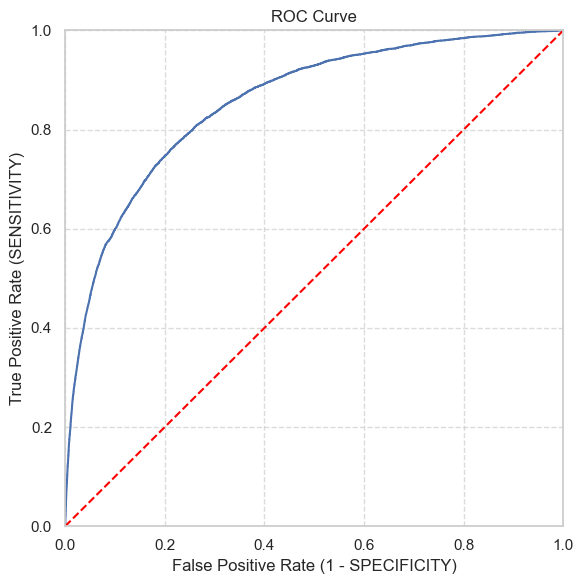

AUC Score: 0.8545613654712879


In [263]:
#here a built in imputer is used to eliminate NANs- why is it needed? didnt we already eliminate them? TO CHECK
imputer = SimpleImputer(strategy='mean')
X_train_array_lr = imputer.fit_transform(X_train_scaled)
X_test_array_lr = imputer.transform(X_test_scaled)

model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train_array_lr, y_train_array)

# Predict probabilities on train set
lr_probs = model.predict_proba(X_train_array_lr)[:, 1]
fpr_lr, tpr_lr, thresh = roc_curve(y_train,lr_probs )
plot_roc_curve(fpr_lr,tpr_lr)
print('AUC Score:', (roc_auc_score(y_train, lr_probs)))


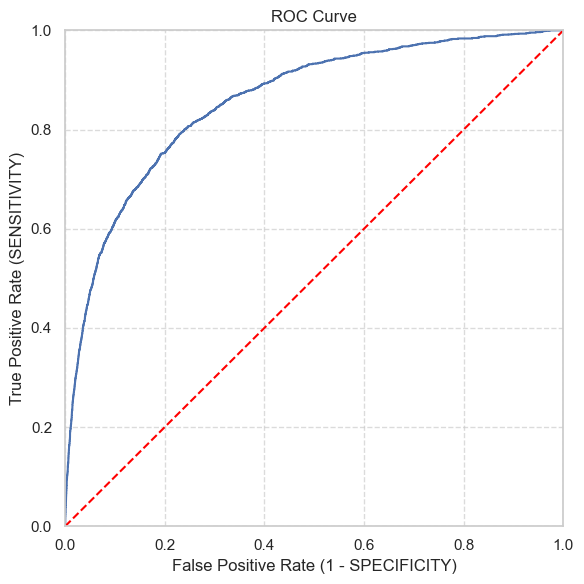

AUC Score: 0.8572982073209685
Threshold: 0.551, Sensitivity: 0.700
Specificity: 0.8436
Flagged as risky: 19.2% of all customers
TP: 1364, FP: 4302, TN: 23200, FN: 584
Total flagged: 5666
Actual defaults in test set: 1948


In [264]:
# predict probabilities on test set
lr_scores_proba = model.predict_proba(X_test_array_lr)
lr_preds = lr_scores_proba[:, 1]

lr_fpr, lr_tpr, thresholds = roc_curve(y_test, lr_preds)
plot_roc_curve(lr_fpr, lr_tpr)
print('AUC Score:', roc_auc_score(y_test, lr_preds))

# Find threshold that gives sensitivity >= 0.7
best_thresh = None
for thresh, sens in zip(thresholds, lr_tpr):
    if sens >= 0.70:
        best_thresh = thresh
        print(f"Threshold: {thresh:.3f}, Sensitivity: {sens:.3f}")
        break

# Apply threshold
y_pred = (lr_preds >= best_thresh).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp)

print(f"Specificity: {specificity:.4f}")
print(f"Flagged as risky: {(tp + fp) / len(y_test) * 100:.1f}% of all customers")
print(f"TP: {tp}, FP: {fp}, TN: {tn}, FN: {fn}")
print(f"Total flagged: {tp + fp}")
print(f"Actual defaults in test set: {tp + fn}")

## ANN

In [265]:
def initialize_params(layers_size):
    np.random.seed(0)
    params = list()
    for i in range(len(layers_size) - 1):
        # Xavier/Glorot Initialization
        W = np.random.randn(layers_size[i + 1], layers_size[i]) * np.sqrt(
            2 / (layers_size[i + 1] + layers_size[i])
        )
        b = np.zeros((layers_size[i + 1], 1))
        params.append((W, b))
    return params

def ANN(x, params):
    layer = x.T
    for i, (W, b) in enumerate(params):
        layer = W @ layer - b
        if i < len(params) - 1:
            layer = jnp.tanh(layer)
        else:
            layer = jax.nn.sigmoid(layer)
    return layer.T

def loss(x, y, params):
    preds = ANN(x, params)
    # ensure y has the same shape as preds
    y = y.reshape(preds.shape)
    # clip to prevent taking log(0) which causes NaNs
    preds = jnp.clip(preds, 1e-15, 1 - 1e-15)
    # Binary Cross-Entropy
    bce = -jnp.mean(y * jnp.log(preds) + (1 - y) * jnp.log(1 - preds))
    l2 = sum(jnp.sum(W**2) for W, b in params) # performing L2 regularization
    lambda_reg=1e-4
    bce= bce + lambda_reg * l2
    return bce

In [266]:
input_size = X_train_array.shape[1]
layers_size = [input_size, 64, 32, 1] # shallow network with non uniform size of layers
num_epochs = 500 # more epochs because MSE is still decresing
learning_rate_max = 1e-1
learning_rate_min = 1e-2
learning_rate_decay = num_epochs
batch_size = 1000

params = initialize_params(layers_size)

grad = jax.jit(jax.grad(loss, argnums=2)) # params is the 3rd argument
loss_jit = jax.jit(loss)
grad_jit = jax.jit(grad)

n_samples = X_train_array.shape[0]

history_train = list()
history_valid = list()

for epoch in range(num_epochs):
    lr = max(
        learning_rate_min, learning_rate_max * (1 - epoch / learning_rate_decay)
    )
    perm = np.random.permutation(n_samples)
    for i in range(0, n_samples, batch_size):
        batch_idx = perm[i : i + batch_size]
        x_batch = X_train_array[batch_idx]
        y_batch = y_train_array[batch_idx]

        grads = grad_jit(x_batch, y_batch, params)
        params = jax.tree_util.tree_map(lambda p, g: p - lr * g, params, grads)

    history_train.append(loss_jit(X_train_array, y_train_array, params))
    history_valid.append(loss_jit(X_test_array, y_test_array, params))

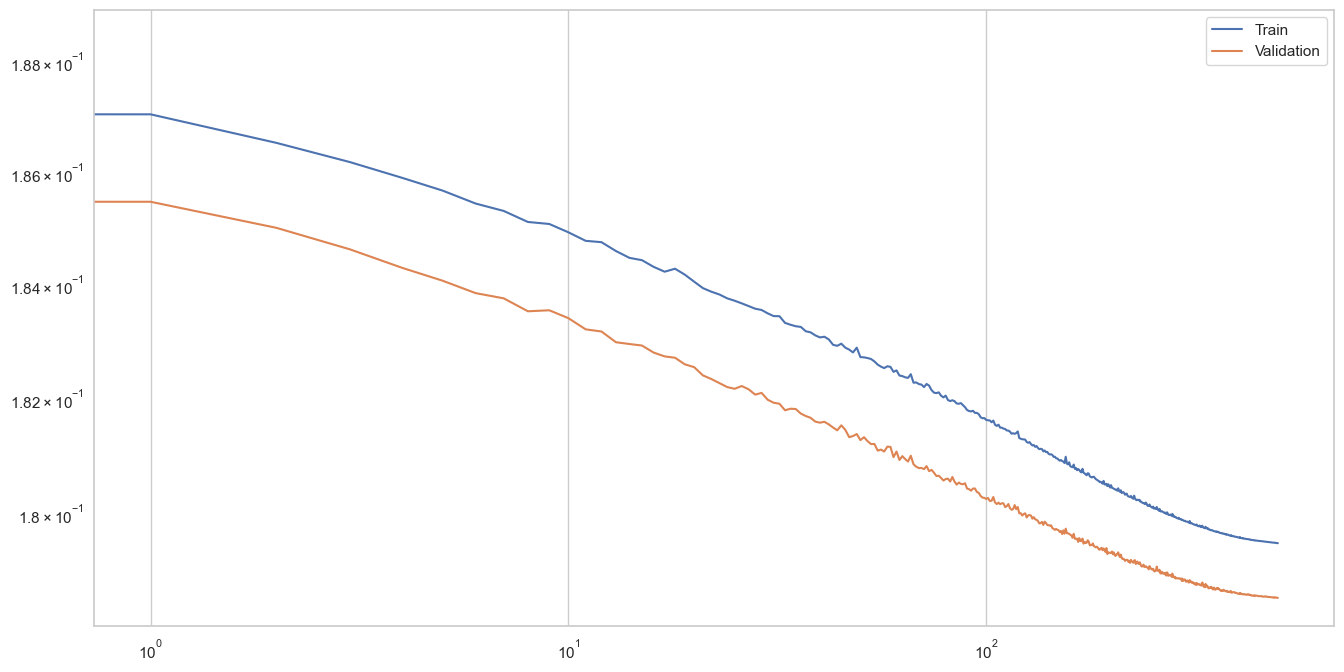

In [267]:
# plotting the loss curves
fig, axs = plt.subplots(1, figsize=(16, 8))
axs.loglog(history_train, label="Train")
axs.loglog(history_valid, label="Validation")
plt.legend()
plt.show()

In [268]:
y_pred_probs = ANN(X_test_array, params)
print('AUC Score:', roc_auc_score(y_test_array, y_pred_probs))

fpr, tpr, thresholds = roc_curve(y_test_array, y_pred_probs)

# Find threshold that gives sensitivity >= 0.7
best_thresh = None
for thresh, sens in zip(thresholds, tpr):
    if sens >= 0.70:
        best_thresh = thresh
        print(f"Threshold: {thresh:.3f}, Sensitivity: {sens:.3f}")
        break

# Apply the threshold here
y_pred = (y_pred_probs >= best_thresh).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test_array, y_pred).ravel()
specificity = tn / (tn + fp)

print(f"Specificity: {specificity:.4f}")
print(f"Flagged as risky: {(tp + fp) / len(y_test_array) * 100:.1f}% of all customers")
print(f"TP: {tp}, FP: {fp}, TN: {tn}, FN: {fn}")
print(f"Total flagged: {tp + fp}")
print(f"Actual defaults in test set: {tp + fn}")

AUC Score: 0.8681820246935187
Threshold: 0.101, Sensitivity: 0.700
Specificity: 0.8634
Flagged as risky: 17.4% of all customers
TP: 1364, FP: 3756, TN: 23746, FN: 584
Total flagged: 5120
Actual defaults in test set: 1948


## Random Forest

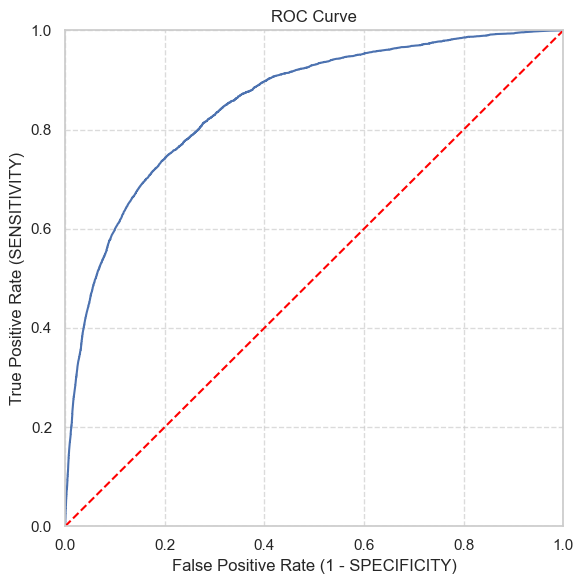

AUC Score: 0.8532096748352578


In [269]:
cl_forest = RandomForestClassifier(random_state=123, max_depth=3, n_estimators=300, class_weight='balanced')
cl_forest.fit(X_train_scaled, y_train)
clf_scores_proba = cl_forest.predict_proba(X_train_scaled)
clf_preds = clf_scores_proba[:, 1]
fpr, tpr, thresh = roc_curve(y_train, clf_preds)
plot_roc_curve(fpr,tpr)
print('AUC Score:', (roc_auc_score(y_train, clf_preds)))

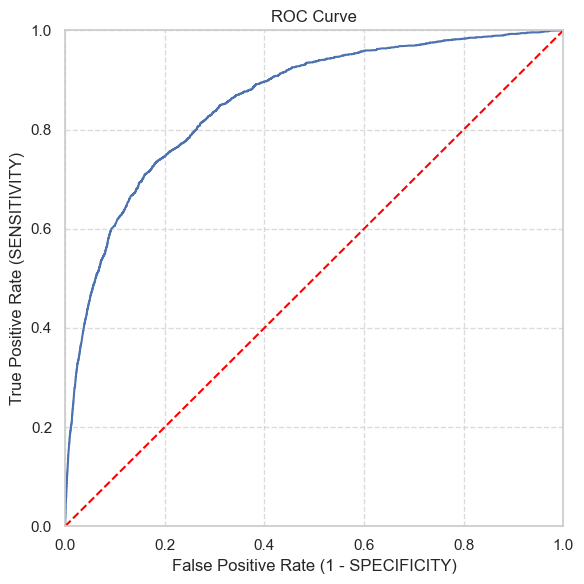

AUC Score: 0.855912187159209
Threshold: 0.539, Sensitivity: 0.701
Specificity: 0.8448
Flagged as risky: 19.1% of all customers
TP: 1365, FP: 4269, TN: 23233, FN: 583
Total flagged: 5634
Actual defaults in test set: 1948


In [270]:
rf_prob = cl_forest.predict_proba(X_test_scaled)
clf_preds = rf_prob[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, clf_preds)
plot_roc_curve(fpr, tpr)
print('AUC Score:', roc_auc_score(y_test, clf_preds))

# Find threshold that gives sensitivity >= 0.7
best_thresh = None
for thresh, sens in zip(thresholds, tpr):
    if sens >= 0.70:
        best_thresh = thresh
        print(f"Threshold: {thresh:.3f}, Sensitivity: {sens:.3f}")
        break

# Apply threshold
y_pred = (clf_preds >= best_thresh).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp)

print(f"Specificity: {specificity:.4f}")
print(f"Flagged as risky: {(tp + fp) / len(y_test) * 100:.1f}% of all customers")
print(f"TP: {tp}, FP: {fp}, TN: {tn}, FN: {fn}")
print(f"Total flagged: {tp + fp}")
print(f"Actual defaults in test set: {tp + fn}")

## XG Boost

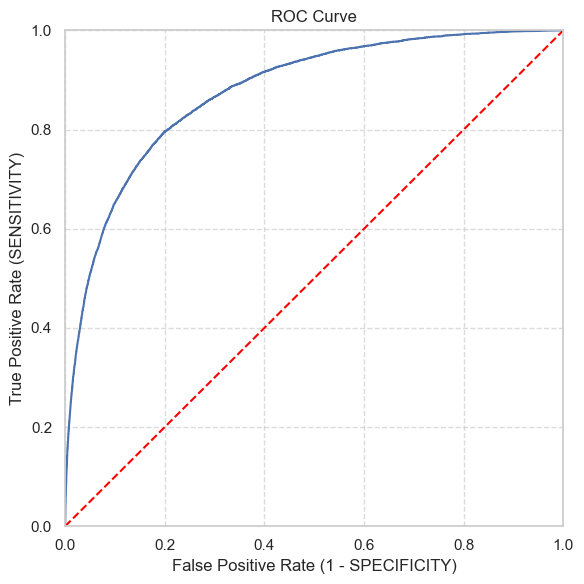

AUC Score: 0.8771317290424379


In [271]:
clf = XGBClassifier(
    random_state=123,
    n_estimators=150,
    learning_rate=0.05,
    max_depth=5,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum()
)

clf.fit(X_train_scaled, y_train)
clf_scores_proba = clf.predict_proba(X_train_scaled)
# clf_scores_proba is a matrix with 2 columns (first one: probability that the sample
# belongs to class 0, second one: probability that the sample belongs to class 1)
clf_preds = clf_scores_proba[:, 1]
fpr, tpr, thresh = roc_curve(y_train, clf_preds)
# roc_curve returns 3 arrays: False Positive Rate (=FP/(FP+TN)), True Positive Rate (=TP/(TP+FN))
# and the thresholds that have been tested
plot_roc_curve(fpr, tpr)
print('AUC Score:', (roc_auc_score(y_train, clf_preds)))

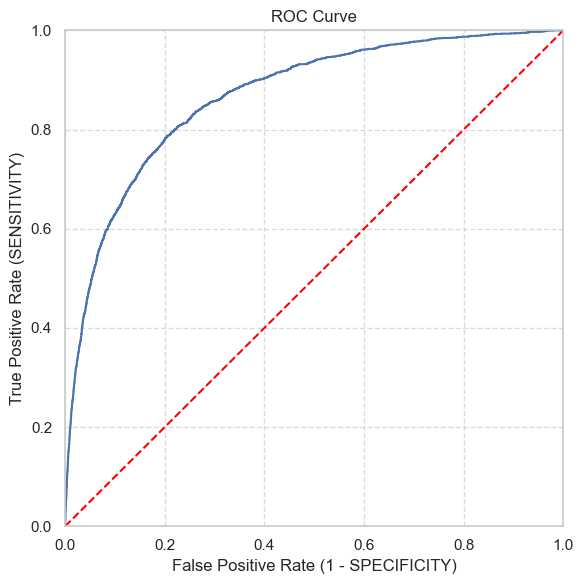

AUC Score: 0.8672754824476459
Accuracy: 79.38%
Threshold: 0.578, Sensitivity: 0.701
Specificity: 0.8591
Flagged as risky: 17.8% of all customers
TP: 1365, FP: 3875, TN: 23627, FN: 583
Total flagged: 5240
Actual defaults in test set: 1948


In [272]:
clf_scores_proba = clf.predict_proba(X_test_scaled)
clf_preds = clf_scores_proba[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, clf_preds)
plot_roc_curve(fpr, tpr)
print('AUC Score:', roc_auc_score(y_test, clf_preds))

accuracy = accuracy_score(y_test, clf.predict(X_test_scaled))
print("Accuracy: %.2f%%" % (accuracy * 100.0))

# Find threshold that gives sensitivity >= 0.7
best_thresh = None
for thresh, sens in zip(thresholds, tpr):
    if sens >= 0.70:
        best_thresh = thresh
        print(f"Threshold: {thresh:.3f}, Sensitivity: {sens:.3f}")
        break

# Apply threshold to proba scores
y_pred = (clf_preds >= best_thresh).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp)

print(f"Specificity: {specificity:.4f}")
print(f"Flagged as risky: {(tp + fp) / len(y_test) * 100:.1f}% of all customers")
print(f"TP: {tp}, FP: {fp}, TN: {tn}, FN: {fn}")
print(f"Total flagged: {tp + fp}")
print(f"Actual defaults in test set: {tp + fn}")

## Ensemble Methodology

In [273]:
# feature engineering
df = train_df
df['IncomePerPerson'] = df['MonthlyIncome'] / (df['NumberOfDependents'] + 1)
df['TotalLate'] = (df['NumberOfTime30-59DaysPastDueNotWorse'] +
                    df['NumberOfTime60-89DaysPastDueNotWorse'] +
                    df['NumberOfTimes90DaysLate'])
df['CreditUtilizationAge'] = df['RevolvingUtilizationOfUnsecuredLines'] / (df['age'] + 1)

X = df.drop(['SeriousDlqin2yrs', 'ID'], axis=1)
y = df['SeriousDlqin2yrs']

# impute before split to get column means, then apply to train/test separately
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=123, stratify=y
)

imputer = SimpleImputer(strategy='median')
X_train_imp = pd.DataFrame(imputer.fit_transform(X_train), columns=X.columns)
X_test_imp  = pd.DataFrame(imputer.transform(X_test),      columns=X.columns)

## LightGBM

In [274]:
#Initializing and training LightGBM
# Hold out a validation set FROM TRAINING DATA ONLY for early stopping
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_imp, y_train, test_size=0.2, random_state=42, stratify=y_train
)

lgb_model = lgb.LGBMClassifier(
    boosting_type='gbdt',
    objective='binary',
    metric='auc',
    learning_rate=0.05,
    n_estimators=1000,
    num_leaves=31,
    class_weight='balanced',
    random_state=123
)

lgb_model.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],   # <-- validation only, never X_test
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)]
)

lgb_test_preds = lgb_model.predict_proba(X_test_imp)[:, 1]
print(f"LightGBM Test AUC: {roc_auc_score(y_test, lgb_test_preds):.4f}")


[LightGBM] [Info] Number of positive: 6234, number of negative: 88006
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001799 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1493
[LightGBM] [Info] Number of data points in the train set: 94240, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
Training until validation scores don't improve for 50 rounds
[100]	valid_0's auc: 0.862571
Early stopping, best iteration is:
[139]	valid_0's auc: 0.862778
LightGBM Test AUC: 0.8652


## Building Augmented Dataset

In [275]:
# Out-Of-Fold
N_FOLDS = 5
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

oof_lgb_preds = np.zeros(len(X_train_imp))   # OOF predictions on train set
test_lgb_folds = np.zeros((len(X_test_imp), N_FOLDS))  # test preds per fold

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_imp, y_train)):
    X_f_tr = X_train_imp.iloc[train_idx]
    y_f_tr = y_train.iloc[train_idx]
    X_f_val = X_train_imp.iloc[val_idx]
    y_f_val = y_train.iloc[val_idx]

    fold_model = lgb.LGBMClassifier(
        boosting_type='gbdt', objective='binary', metric='auc',
        learning_rate=0.05, n_estimators=500,
        num_leaves=31, class_weight='balanced', random_state=123
    )
    fold_model.fit(
        X_f_tr, y_f_tr,
        eval_set=[(X_f_val, y_f_val)],
        callbacks=[lgb.early_stopping(50), lgb.log_evaluation(200)]
    )

    oof_lgb_preds[val_idx] = fold_model.predict_proba(X_f_val)[:, 1]
    test_lgb_folds[:, fold] = fold_model.predict_proba(X_test_imp)[:, 1]
    print(f"Fold {fold+1} AUC: {roc_auc_score(y_f_val, oof_lgb_preds[val_idx]):.4f}")

test_lgb_meta = test_lgb_folds.mean(axis=1)  # average across folds for test
print(f"\nOOF AUC: {roc_auc_score(y_train, oof_lgb_preds):.4f}")

# Build augmented datasets using OOF (no leakage)
X_train_aug = X_train_imp.copy()
X_train_aug['lgb_meta'] = oof_lgb_preds   # OOF preds with rows that the model never saw

X_test_aug = X_test_imp.copy()
X_test_aug['lgb_meta'] = test_lgb_meta

[LightGBM] [Info] Number of positive: 6235, number of negative: 88005
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002024 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1494
[LightGBM] [Info] Number of data points in the train set: 94240, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[97]	valid_0's auc: 0.861826
Fold 1 AUC: 0.8618
[LightGBM] [Info] Number of positive: 6235, number of negative: 88005
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001848 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[Ligh

## New XGBoost

In [276]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_aug, y_train, test_size=0.2, random_state=42, stratify=y_train
)

# Same random_state as original split — no re-splitting
xgb_model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    random_state=123,
    eval_metric='auc',
    early_stopping_rounds=50
)

xgb_model.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],  # for monitoring only, not early stopping source of truth ideally
    verbose=100
)

xgb_test_preds = xgb_model.predict_proba(X_test_aug)[:, 1]
print(f"XGBoost Test AUC: {roc_auc_score(y_test, xgb_test_preds):.4f}")

[0]	validation_0-auc:0.85871
[81]	validation_0-auc:0.85974
XGBoost Test AUC: 0.8657


## CatBoost

In [277]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_imp, y_train, test_size=0.2, random_state=42, stratify=y_train
)

cat_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    auto_class_weights='Balanced',
    random_seed=123,
    eval_metric='AUC',
    verbose=100
)

cat_model.fit(
    X_tr, y_tr,
    eval_set=(X_val, y_val),
    early_stopping_rounds=50
)

cat_test_preds = cat_model.predict_proba(X_test_imp)[:, 1]
print(f"CatBoost Test AUC: {roc_auc_score(y_test, cat_test_preds):.4f}")

0:	test: 0.8408314	best: 0.8408314 (0)	total: 13.6ms	remaining: 6.8s
100:	test: 0.8624651	best: 0.8624651 (100)	total: 1.22s	remaining: 4.81s
200:	test: 0.8637317	best: 0.8637317 (200)	total: 2.38s	remaining: 3.53s
300:	test: 0.8638933	best: 0.8641014 (294)	total: 3.55s	remaining: 2.35s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.8641013868
bestIteration = 294

Shrink model to first 295 iterations.
CatBoost Test AUC: 0.8687


## Weighted Ensemble

In [ ]:
def normalized_gini(y_true, y_pred):
    return 2 * roc_auc_score(y_true, y_pred) - 1

# def default_rate_at_4pct(y_true, y_pred):
#     """Percentage of actual defaults captured in top 4% of predictions."""
#     threshold_idx = int(np.ceil(0.04 * len(y_pred)))
#     top_idx = np.argsort(y_pred)[::-1][:threshold_idx]
#     return y_true.iloc[top_idx].sum() / y_true.sum()

# def competition_metric(y_true, y_pred):
#     G = normalized_gini(y_true, y_pred)
#     D = default_rate_at_4pct(y_true, y_pred)
#     return 0.5 * (G + D)

w_lgb = 0.4
w_xgb = 0.4
w_cat = 0.2

final_preds = (w_lgb * test_lgb_meta +
               w_xgb * xgb_test_preds +
               w_cat * cat_test_preds)

print(f"Ensemble AUC:              {roc_auc_score(y_test, final_preds):.4f}")
print(f"Normalized Gini (G):       {normalized_gini(y_test, final_preds):.4f}")

Ensemble AUC:              0.8680
Normalized Gini (G):       0.7360
